# LSTM Notebook

This notebook provides an example of working with the LSTM model. It
shows the process of loading per-game data for premier league forwards for
the current season, splitting into train/test sets, creating datasets and
dataloaders from them, training a `FootballLSTM` instance, and evaluating
it.

In [1]:
import sys
import os
from understatapi import UnderstatClient
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
from matplotlib import pyplot as plt

# Also import local helpers
target_dir = os.path.abspath('..') 

if target_dir not in sys.path:
    sys.path.append(target_dir)
    
from preprocess import get_position_players_stats_df, CustomFootballDataset
from football_lstm import FootballLSTM

In [2]:
# Create understat connection
understat = UnderstatClient()

In [3]:
# Choose what stats to forecast, and how many past games to use to predict
# the current one
stats = ["goals", "xG", "assists", "xA", "key_passes", "xGChain", "xGBuildup"]
games_per_block = 10

In [ ]:
# Get forward stats for all seasons in top 5 leagues
# leagues = ["EPL", "La_Liga", "Bundesliga", "Serie_A", "Ligue_1"]
leagues = ["EPL"]
seasons = [2021,2022,2023,2024,2025]

# save dataset to csv to avoid pulls

f_stats = get_position_players_stats_df(understat, ['F'], games_per_block, stats, leagues=leagues, seasons=seasons)
f_stats.head()

goals_per_90  xG_per_90  assists_per_90  xA_per_90  \
player_id date                                                             
8941      2021-02-27      0.000000   0.088354        0.000000   0.032106   
          2021-05-13      0.000000   0.035813        0.000000   0.037693   
          2021-10-22      0.159292   0.115377        0.000000   0.038980   
          2022-01-15      0.256776   0.166128        0.128388   0.152694   
          2022-04-02      0.309989   0.125646        0.000000   0.038886   

                      key_passes_per_90  xGChain_per_90  xGBuildup_per_90  
player_id date                                                             
8941      2021-02-27           0.753138        0.112552          0.033716  
          2021-05-13           1.046512        0.590242          0.560005  
          2021-10-22           0.955752        0.322148          0.208972  
          2022-01-15           0.770328        0.439601          0.130282  
          2022-04-02           0.619977        0.404277          0.258364

In [5]:
# Train/test split
train_len = int(len(f_stats) * 0.8)
train_df = f_stats.iloc[:train_len]
test_df = f_stats.iloc[train_len:]

In [6]:
train_df.head()

goals_per_90  xG_per_90  assists_per_90  xA_per_90  \
player_id date                                                             
8941      2021-02-27      0.000000   0.088354        0.000000   0.032106   
          2021-05-13      0.000000   0.035813        0.000000   0.037693   
          2021-10-22      0.159292   0.115377        0.000000   0.038980   
          2022-01-15      0.256776   0.166128        0.128388   0.152694   
          2022-04-02      0.309989   0.125646        0.000000   0.038886   

                      key_passes_per_90  xGChain_per_90  xGBuildup_per_90  
player_id date                                                             
8941      2021-02-27           0.753138        0.112552          0.033716  
          2021-05-13           1.046512        0.590242          0.560005  
          2021-10-22           0.955752        0.322148          0.208972  
          2022-01-15           0.770328        0.439601          0.130282  
          2022-04-02           0.619977        0.404277          0.258364

In [ ]:
# Create datasets
blocks_per_input = 5

train_dataset = CustomFootballDataset(train_df, blocks_per_input, multiple_players=True)
test_dataset = CustomFootballDataset(test_df, blocks_per_input, multiple_players=True)

In [8]:
len(train_dataset)

2855

In [9]:
# Create dataloaders

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True
)

test_dataloader = DataLoader(
    dataset=test_dataset,
    batch_size=32,
    shuffle=False
)

In [10]:
# Loss function, optimizer, epochs
LOSS_FN = nn.MSELoss()

In [11]:
# Tuning params
params = {
    "learning_rates": [0.1, 0.001, 0.0001, 0.00001],
    "epochs": [10, 30, 50],
    "h_sizes": [16, 32, 64], # 128
    "layers": [1, 2, 4],
    "dropouts": [0.3, 0.5, 0.7]
}

# Hyperparameter tuning
best_combo = None
previous_best = None

for lr in params['learning_rates']:
    for epoch in params['epochs']:
        for layer in params['layers']:
            for h_size in params['h_sizes']:
                for dropout in params['dropouts']:
        
                    # model and optimizer setup

                    # non-zero dropout expects num_layers greater than 1 so train with dropout set to 0
                    if layer == 1:
                        model = FootballLSTM(n_features=len(f_stats.columns), hidden_size=h_size, num_layers=layer, dropout=0)
                    else:
                        model = FootballLSTM(n_features=len(f_stats.columns), hidden_size=h_size, num_layers=layer, dropout=dropout)
                        
                    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
                    
                    # Train model
                    train_losses, test_losses = model.train_model(
                        optimizer=optimizer,
                        loss_fn=LOSS_FN,
                        train_dataloader=train_dataloader,
                        test_dataloader=test_dataloader,
                        n_epochs=epoch
                    )

                    # model evaluation
                    rmse, mae = model.eval_model(test_dataloader)

                    if best_combo == None or previous_best == None:
                        best_combo = [lr, epoch, layer, h_size, 0 if layer == 1 else dropout]
                        previous_best = rmse
                    elif rmse < previous_best:
                        best_combo = [lr, epoch, layer, h_size, 0 if layer == 1 else dropout]
                        previous_best = rmse
                    else:
                        continue

plt.plot(train_losses, color="red", label="Train loss")
plt.plot(test_losses, color="blue", label="Test loss")
plt.legend()
plt.title(f"""Hyperparameter Tuning - Train vs Test Loss ({best_combo[0]}, {best_combo[1]}, 
          {best_combo[2]}, {best_combo[3]}, {best_combo[4]})""")
plt.savefig(f"tuning_graphs/"f"lr{lr}_ep{epoch}_ly{layer}_hs{h_size}_do{dropout}.png")
plt.close()

print(f"""
      Best Hyperparameter setup \n
      - learning rate: {best_combo[0]} 
      - number of epochs: {best_combo[1]}.
      - number of layers: {best_combo[2]}.
      - hidden size: {best_combo[3]}.
      - dropout: {best_combo[4]}.
      """)


      Best Hyperparameter setup 

      - learning rate: 0.0001 
      - number of epochs: 50.
      - number of layers: 1.
      - hidden size: 64.
      - dropout: 0.
      


In [12]:
# Tuned setup
optimizer = torch.optim.Adam(model.parameters(), lr=best_combo[0])
num_epochs = best_combo[1]
tuned_model = FootballLSTM(n_features=len(f_stats.columns), hidden_size=best_combo[3], num_layers=best_combo[2], dropout=best_combo[4])

# Train model
train_losses, test_losses = tuned_model.train_model(
    optimizer=optimizer,
    loss_fn=LOSS_FN,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    n_epochs=num_epochs
)

In [13]:
# Evaluate test performance

rmse, mae = tuned_model.eval_model(test_dataloader)
print(f"Test RMSE: {rmse}")
print(f"Test MAE: {mae}")

Test RMSE: 0.6085143089294434
Test MAE: 0.5262648463249207


RMSE: 0.6642903685569763
MAE: 0.6399469375610352
goals_per_90 RMSE: 0.9422584772109985
goals_per_90 MAE: 0.907871663570404
xG_per_90 RMSE: 0.9461336135864258
xG_per_90 MAE: 0.9356464743614197
assists_per_90 RMSE: 0.2873374819755554
assists_per_90 MAE: 0.2475944608449936
xA_per_90 RMSE: 0.32762396335601807
xA_per_90 MAE: 0.3223094344139099
key_passes_per_90 RMSE: 1.0134847164154053
key_passes_per_90 MAE: 0.9488117694854736
xGChain_per_90 RMSE: 0.9362874627113342
xGChain_per_90 MAE: 0.9271853566169739
xGBuildup_per_90 RMSE: 0.19690640270709991
xGBuildup_per_90 MAE: 0.19020956754684448


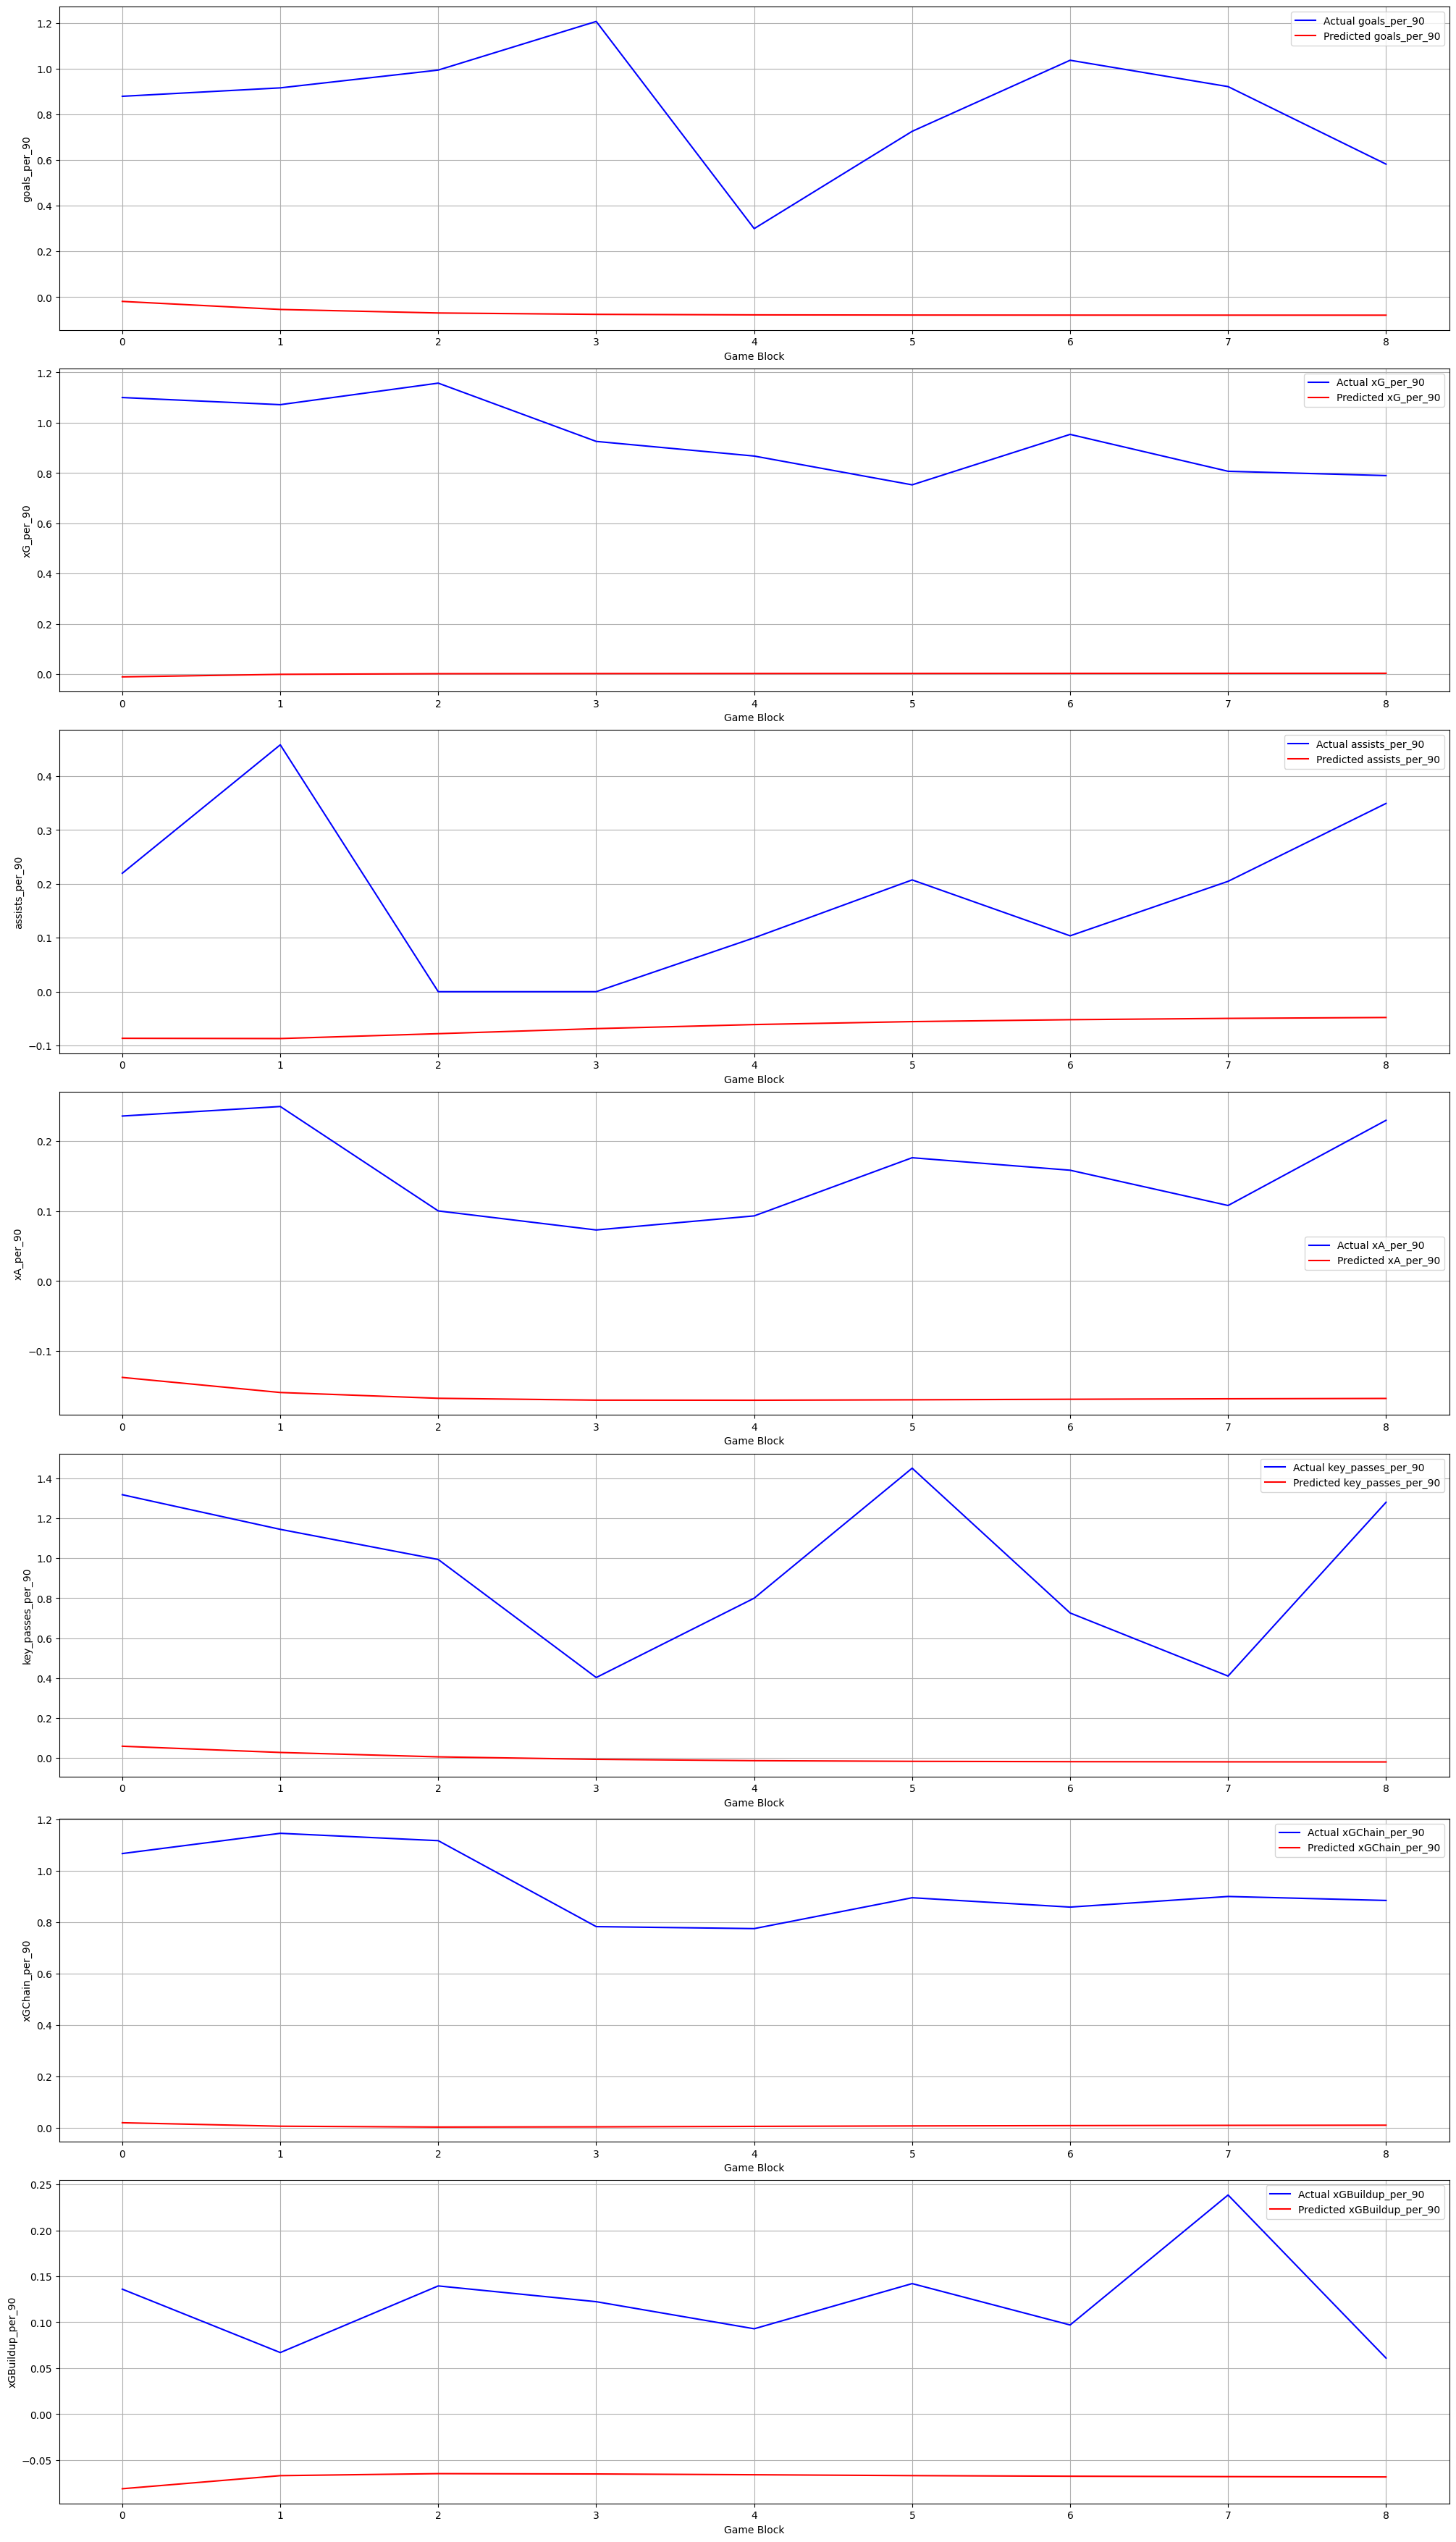

In [14]:
# See how model does on forecasting a specific player--Erling Haaland

haaland_df = f_stats.loc["8260"]

tuned_model.eval_model_on_player(haaland_df)